# Wykrywanie anomali dla MNIST

In [40]:
import numpy as np
from torchvision import datasets, transforms

transform = transforms.ToTensor()

mnist_train = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
mnist_test = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

x_train, Y_train = mnist_train.data.numpy(), mnist_train.targets.numpy()
x_test, Y_test = mnist_test.data.numpy(), mnist_test.targets.numpy()

x = np.concatenate([x_train, x_test], axis=0)
Y = np.concatenate([Y_train, Y_test], axis=0)
print(x.shape) 
print(Y.shape)

(70000, 28, 28)
(70000,)


**Transform 28 x 28 -> 1 x 784**

In [47]:
x_flat = x.reshape(x.shape[0], -1)
print(x_flat.shape, x_flat.shape)

(70000, 784) (70000, 784)


**Clustering using Kmeans**

In [48]:
from sklearn.cluster import KMeans
import pandas as pd


kmeans = KMeans(n_clusters=10)
labels = kmeans.fit_predict(x_flat)
centroids = kmeans.cluster_centers_

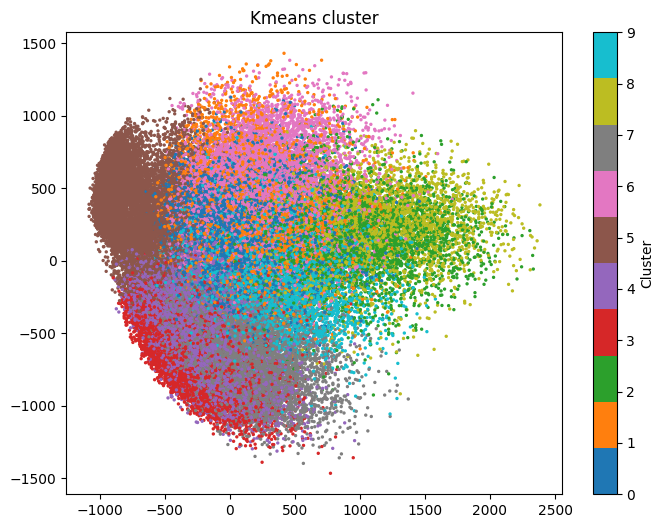

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_flat)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels, cmap='tab10', s=2)
plt.title("Kmeans cluster")
plt.colorbar(scatter, label='Cluster')
plt.show()

**Measuring distances to the centroid and finding threshold based on percentile**

In [72]:
def distanace_to_centroid(x, centorid):
    return np.linalg.norm(x - centorid)


distances = np.array([
    distanace_to_centroid(x, centroids[labels[i]]) for i, x in enumerate(x_flat)
])
threshold = np.percentile(distances, 99.986)

print(threshold)

2602.0880250501436


**Creating outlier mask and finding anomalies**

In [83]:
outlier_mask = distances > threshold
outlier_nums = x[outlier_mask]
outlier_true_labels = Y[outlier_mask]

outlier_distances = distances[outlier_mask]
sorted_idx = np.argsort(-outlier_distances)

len_of_outlier = sum(1 if i else 0 for i in outlier_mask)
print(len_of_outlier)
print(sorted_idx)
print(outlier_distances)

10
[2 5 9 0 6 1 4 7 3 8]
[2659.12861129 2653.3825522  2915.96637045 2625.48418868 2646.41250692
 2820.39317099 2657.64553522 2639.27049852 2602.74001266 2663.09968156]


**Visualizing results**

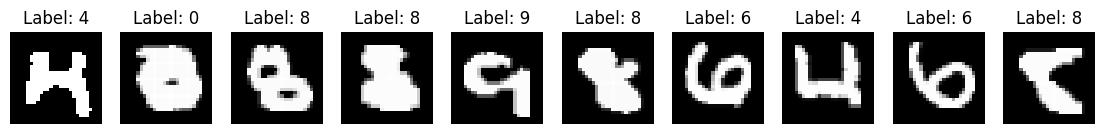

In [82]:
plt.figure(figsize=(14, 2))
for i in range(len_of_outlier):
    mapped_index = sorted_idx[i]
    
    plt.subplot(1, len_of_outlier, i + 1)
    plt.imshow(outlier_nums[mapped_index], cmap='gray')
    plt.title(f"Label: {outlier_true_labels[mapped_index]}")
    plt.axis('off')
plt.show()

# MNIST + losowe obrazki

In [1]:
import glob
import numpy as np
from PIL import Image

paths = glob.glob("data/my_imgs_1/*.png")
imgs = []

for path in paths:
    img = Image.open(path).convert("L").resize((28, 28))
    imgs.append(np.array(img))
imgs = np.array(imgs)

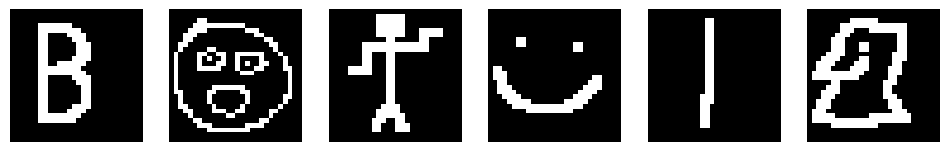

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

In [3]:
import numpy as np
from torchvision import datasets, transforms

transform = transforms.ToTensor()

mnist_train = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
mnist_test = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

x_train, Y_train = mnist_train.data.numpy(), mnist_train.targets.numpy()
x_test, Y_test = mnist_test.data.numpy(), mnist_test.targets.numpy()

x = np.concatenate([x_train, x_test, imgs], axis=0)
Y = np.concatenate(
    [Y_train, Y_test, [np.random.randint(0, 10) for _ in range(len(imgs))]], axis=0
)

print(x.shape, Y.shape, len(imgs))

(70006, 28, 28) (70006,) 6


In [4]:
from sklearn.cluster import KMeans
x_flat = x.reshape(x.shape[0], -1)


kmeans = KMeans(n_clusters=10)
labels = kmeans.fit_predict(x_flat)
centroids = kmeans.cluster_centers_

In [5]:
def distanace_to_centroid(x, centorid):
    return np.linalg.norm(x - centorid)


distances = np.array([
    distanace_to_centroid(x, centroids[labels[i]]) for i, x in enumerate(x_flat)
])
threshold = np.percentile(distances, 99.986)

print(threshold)

2639.920038913835


In [7]:
outlier_mask = distances > threshold
outlier_nums = x[outlier_mask]
outlier_true_labels = labels[outlier_mask]

outlier_distances = distances[outlier_mask]
sorted_idx = np.argsort(-outlier_distances)

len_of_outlier = sum(1 if i else 0 for i in outlier_mask)
print(len_of_outlier)
print(sorted_idx)
print(outlier_distances)

10
[9 7 2 4 8 6 1 3 0 5]
[2643.28411497 2662.36119269 2915.89784277 2647.20455958 2789.66374943
 2642.90787901 2666.94126084 3007.33182305 2674.20048054 3272.17183758]


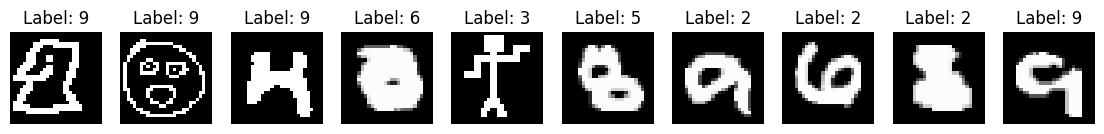

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 2))
for i in range(len_of_outlier):
    mapped_index = sorted_idx[i]
    
    plt.subplot(1, len_of_outlier, i + 1)
    plt.imshow(outlier_nums[mapped_index], cmap='gray')
    plt.title(f"Label: {outlier_true_labels[mapped_index]}")
    plt.axis('off')
plt.show()

## Ranking for our pictures

In [9]:
import matplotlib.pyplot as plt

ranking = np.argsort(-distances)

N = len(imgs)  # imgs = tablica z własnymi obrazkami
own_img_indices = np.arange(len(x) - N, len(x))

results = np.array([np.where(ranking == idx)[0][0] + 1 for idx in own_img_indices])
img_idx_sorted = np.argsort(-results)
print(img_idx_sorted)

[4 3 0 2 1 5]


In [12]:
print(own_img_indices)
own_labels = [labels[i] for i in own_img_indices]
print(own_labels)

[70000 70001 70002 70003 70004 70005]
[np.int32(8), np.int32(9), np.int32(3), np.int32(8), np.int32(7), np.int32(9)]


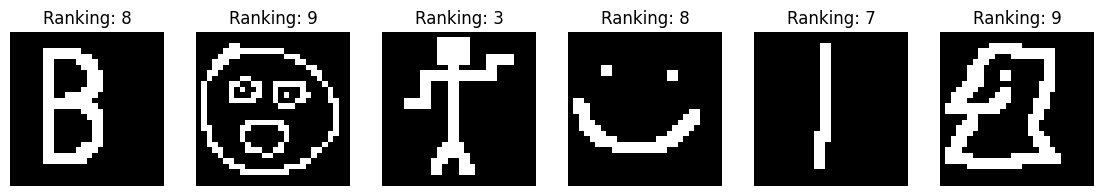

In [13]:

plt.figure(figsize=(14, 2))
n = 5
for i in range(len(imgs)):
    super_idx = np.where(img_idx_sorted == n)[0][0]
    plt.subplot(1, len(imgs), i + 1)
    plt.imshow(imgs[i], cmap='gray')
    plt.title(f"Ranking: {own_labels[i]}")
    plt.axis('off')
    n-=1
plt.show()